In [1]:
import pandas as pd
import os

In [2]:
colunas = [
    'NU_ANO_CENSO',
    'CO_ENTIDADE',
    'QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE',
    'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF',
    'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC',
    'QT_MAT_EJA',
    'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE',
    'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF',
    'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC',
    'QT_DOC_EJA',
    'IN_EJA'
]

In [3]:
caminhos = {
    2022: '../data/microdados_censo_escolar_2022/microdados/dados/microdados_ed_basica_2022.csv',
    2023: '../data/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv',
    2024: '../data/microdados_censo_escolar_2024/dados/microdados_ed_basica_2024.csv'
}

In [4]:
dfs = []
for ano, caminho in caminhos.items():
    print(f'Lendo dados de {ano}...')
    df_ano = pd.read_csv(caminho, encoding='latin-1', sep=';', low_memory=False, usecols=colunas)
    dfs.append(df_ano)
    print(f'{ano}: {df_ano.shape[0]} escolas carregadas')

Lendo dados de 2022...
2022: 224649 escolas carregadas
Lendo dados de 2023...
2023: 217625 escolas carregadas
Lendo dados de 2024...
2024: 215545 escolas carregadas


In [5]:
df = pd.concat(dfs, ignore_index=True)
print(f'DataFrame consolidado: {df.shape[0]} registros x {df.shape[1]} colunas')
df.head()

DataFrame consolidado: 657819 registros x 24 colunas


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
0,2022,11022558,0.0,6.0,0.0,0.0,0.0,6.0,6.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2,2022,11024291,0.0,9.0,0.0,0.0,0.0,9.0,9.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2022,11024372,0.0,118.0,17.0,0.0,17.0,101.0,43.0,58.0,...,1.0,0.0,1.0,7.0,1.0,6.0,0.0,0.0,0.0,0.0
4,2022,11024666,0.0,161.0,18.0,0.0,18.0,143.0,66.0,77.0,...,1.0,0.0,1.0,19.0,3.0,16.0,0.0,0.0,0.0,0.0


In [6]:
# Filtrar escolas com EJA
df_eja = df[df['IN_EJA'] == 1].copy()
print(f'Total de escolas com EJA: {len(df_eja)}')
df_eja.head()

Total de escolas com EJA: 89405


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA
1,2022,11024275,1.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
37,2022,11006757,1.0,666.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0
39,2022,11006773,1.0,1434.0,0.0,0.0,0.0,1193.0,0.0,1193.0,...,0.0,0.0,0.0,41.0,0.0,41.0,0.0,0.0,0.0,13.0
50,2022,11007281,1.0,620.0,0.0,0.0,0.0,466.0,0.0,466.0,...,0.0,0.0,0.0,21.0,0.0,21.0,0.0,0.0,0.0,15.0
53,2022,11007451,1.0,950.0,0.0,0.0,0.0,818.0,678.0,140.0,...,0.0,0.0,0.0,28.0,27.0,9.0,0.0,0.0,0.0,12.0


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use('seaborn-v0_8')

In [16]:
# Remover outliers baseados em QT_MAT_BAS usando desvio-padrão
mean_mat_bas = df_eja['QT_MAT_BAS'].mean()
std_mat_bas = df_eja['QT_MAT_BAS'].std()

# Definir limite: 3 desvios-padrão da média
limite_superior = mean_mat_bas + 3 * std_mat_bas
limite_inferior = mean_mat_bas - 3 * std_mat_bas

print(f'Média QT_MAT_BAS: {mean_mat_bas:.2f}')
print(f'Desvio-padrão QT_MAT_BAS: {std_mat_bas:.2f}')
print(f'Limite inferior: {limite_inferior:.2f}')
print(f'Limite superior: {limite_superior:.2f}')

# Filtrar outliers
df_eja_sem_outliers = df_eja[(df_eja['QT_MAT_BAS'] >= limite_inferior) & (df_eja['QT_MAT_BAS'] <= limite_superior)].copy()

print(f'\nTotal antes da remoção: {len(df_eja)}')
print(f'Total após remoção: {len(df_eja_sem_outliers)}')
print(f'Outliers removidos: {len(df_eja) - len(df_eja_sem_outliers)}')

# Atualizar df_eja
df_eja = df_eja_sem_outliers

Média QT_MAT_BAS: 407.16
Desvio-padrão QT_MAT_BAS: 474.50
Limite inferior: -1016.33
Limite superior: 1830.64

Total antes da remoção: 89405
Total após remoção: 88685
Outliers removidos: 720


In [17]:
# Preparar dados para clusterização
colunas_cluster = [col for col in df_eja.columns if col not in ['NU_ANO_CENSO', 'CO_ENTIDADE', 'IN_EJA']]
df_cluster = df_eja[colunas_cluster].copy()

# Tratar valores nulos - preencher com 0
df_cluster = df_cluster.fillna(0)

print(f'Dados para clusterização: {df_cluster.shape[0]} registros x {df_cluster.shape[1]} colunas')
print(f'Colunas usadas: {colunas_cluster}')

Dados para clusterização: 88685 registros x 22 colunas
Colunas usadas: ['QT_MAT_BAS', 'QT_MAT_INF', 'QT_MAT_INF_CRE', 'QT_MAT_INF_PRE', 'QT_MAT_FUND', 'QT_MAT_FUND_AI', 'QT_MAT_FUND_AF', 'QT_MAT_MED', 'QT_MAT_PROF', 'QT_MAT_PROF_TEC', 'QT_MAT_EJA', 'QT_DOC_INF', 'QT_DOC_INF_CRE', 'QT_DOC_INF_PRE', 'QT_DOC_FUND', 'QT_DOC_FUND_AI', 'QT_DOC_FUND_AF', 'QT_DOC_MED', 'QT_DOC_PROF', 'QT_DOC_PROF_TEC', 'QT_DOC_EJA', 'cluster']


In [18]:
# Escalar os dados
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print(f'Dados escalados: {df_scaled.shape}')
print(f'Média por feature (após escala): {df_scaled.mean(axis=0)[:5]}')
print(f'Desvio padrão por feature (após escala): {df_scaled.std(axis=0)[:5]}')

Dados escalados: (88685, 22)
Média por feature (após escala): [-7.69150393e-18 -3.65346437e-17 -2.05106772e-17 -3.52527264e-17
 -4.48671063e-17]
Desvio padrão por feature (após escala): [1. 1. 1. 1. 1.]


In [19]:
# Método do cotovelo para encontrar número ideal de clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    print(k)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotar método do cotovelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', markersize=8)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exibir valores
print('Valores de Inércia:', dict(zip(k_range, inertias)))
print('Valores de Silhouette:', dict(zip(k_range, silhouette_scores)))

2


KeyboardInterrupt: 

In [20]:
# Treinar KMeans com k ótimo (baseado no método do cotovelo e silhouette)
k_optimo = 4  # Ajuste este valor após analisar os gráficos anteriores
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans.fit(df_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f'KMeans treinado com k={k_optimo}')
print(f'Inércia: {kmeans.inertia_:.2f}')
print(f'Distribuição dos clusters: {np.bincount(labels)}')

KMeans treinado com k=4
Inércia: 1085816.11
Distribuição dos clusters: [ 5918 60823 20659  1285]


In [21]:
# Calcular métricas de avaliação do cluster
silhouette_avg = silhouette_score(df_scaled, labels)
calinski_harabasz = calinski_harabasz_score(df_scaled, labels)
davies_bouldin = davies_bouldin_score(df_scaled, labels)

print('Métricas de Avaliação do Cluster:')
print(f'  Silhouette Score: {silhouette_avg:.4f} (varia de -1 a 1, quanto maior melhor)')
print(f'  Calinski-Harabasz Index: {calinski_harabasz:.2f} (quanto maior melhor)')
print(f'  Davies-Bouldin Index: {davies_bouldin:.4f} (quanto menor melhor)')
print(f'  Inércia: {kmeans.inertia_:.2f}')

Métricas de Avaliação do Cluster:
  Silhouette Score: 0.3956 (varia de -1 a 1, quanto maior melhor)
  Calinski-Harabasz Index: 23555.73 (quanto maior melhor)
  Davies-Bouldin Index: 1.0892 (quanto menor melhor)
  Inércia: 1085816.11


In [22]:
# Adicionar coluna de cluster ao df_eja
df_eja['cluster'] = labels

print(f'Coluna cluster adicionada ao df_eja')
print(f'Distribuição de escolas por cluster:')
print(df_eja['cluster'].value_counts().sort_index())

Coluna cluster adicionada ao df_eja
Distribuição de escolas por cluster:
cluster
0     5918
1    60823
2    20659
3     1285
Name: count, dtype: int64


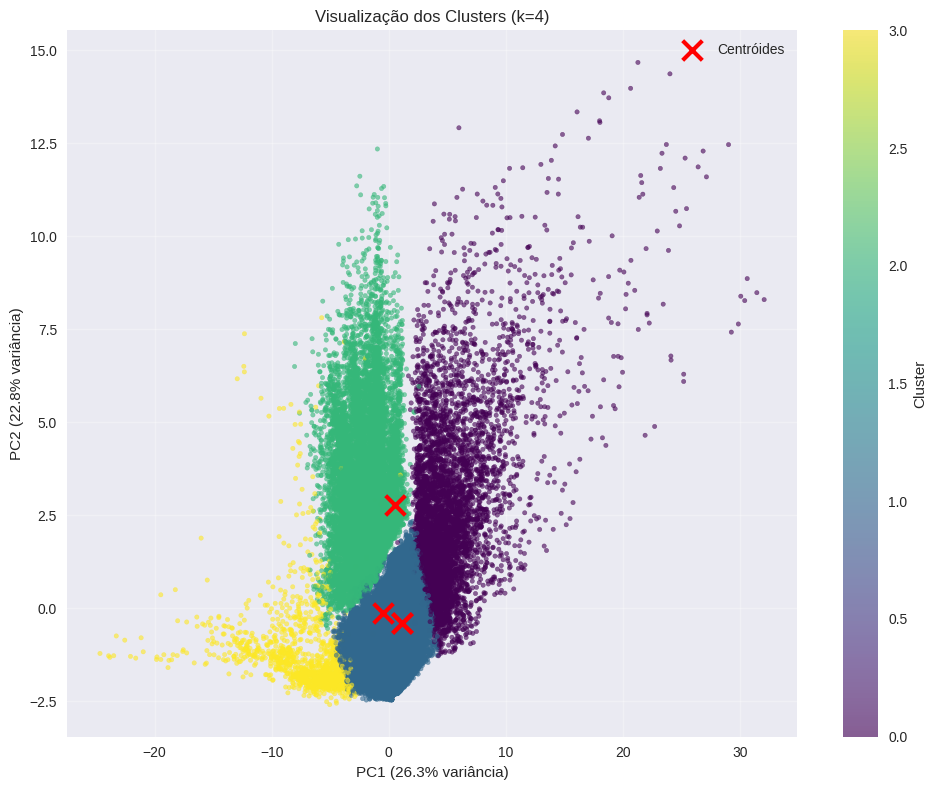

Variância explicada pelos 2 primeiros componentes: 49.12%


In [23]:
# Visualizar clusters usando PCA para redução de dimensionalidade
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Plotar clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centróides')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title(f'Visualização dos Clusters (k={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Variância explicada pelos 2 primeiros componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%')

In [24]:
# Exibir centróides na escala original (antes do Scaler)
centroids_original = scaler.inverse_transform(centroids)
df_centroids = pd.DataFrame(centroids_original, columns=colunas_cluster)

print(f'Centróides dos {k_optimo} clusters (valores originais):')
print(df_centroids.T)

Centróides dos 4 clusters (valores originais):
                          0           1           2           3
QT_MAT_BAS       594.783916  221.556822  799.843700  795.288716
QT_MAT_INF       120.969421   11.145589    1.701438    0.751751
QT_MAT_INF_CRE    24.029397    3.698201    0.122804    0.304280
QT_MAT_INF_PRE    96.940024    7.447387    1.578634    0.447471
QT_MAT_FUND      395.757223   78.288399  513.098601   26.481712
QT_MAT_FUND_AI   291.418483   46.888494  146.041096    3.278599
QT_MAT_FUND_AF   104.338740   31.399905  367.057505   23.203113
QT_MAT_MED         2.809934   64.199451  160.195072  481.435019
QT_MAT_PROF        2.026694    7.172569   11.223680  591.156420
QT_MAT_PROF_TEC    0.364420    4.587156    7.098504  580.921401
QT_MAT_EJA        74.745903   65.954326  121.459993  121.252918
QT_DOC_INF         8.601960    0.882838    0.109395    0.057588
QT_DOC_INF_CRE     2.200710    0.268439    0.009971    0.022568
QT_DOC_INF_PRE     6.779355    0.666206    0.101215    0.

In [25]:
# Listar escolas do cluster 3
escolas_cluster_3 = df_eja[df_eja['cluster'] == 3]
print(f'Total de escolas no cluster 3: {len(escolas_cluster_3)}')
escolas_cluster_3

Total de escolas no cluster 3: 1285


,NU_ANO_CENSO,CO_ENTIDADE,IN_EJA,QT_MAT_BAS,QT_MAT_INF,QT_MAT_INF_CRE,QT_MAT_INF_PRE,QT_MAT_FUND,QT_MAT_FUND_AI,QT_MAT_FUND_AF,...,QT_DOC_INF_CRE,QT_DOC_INF_PRE,QT_DOC_FUND,QT_DOC_FUND_AI,QT_DOC_FUND_AF,QT_DOC_MED,QT_DOC_PROF,QT_DOC_PROF_TEC,QT_DOC_EJA,cluster
2446,2022,12028843,1.0,871.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,33.0,33.0,1.0,3
4515,2022,13116401,1.0,531.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,32.0,32.0,32.0,14.0,3
4641,2022,13101153,1.0,434.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,30.0,30.0,30.0,12.0,3
4953,2022,13101137,1.0,399.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,28.0,30.0,30.0,6.0,3
6120,2022,13026844,1.0,971.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,65.0,85.0,85.0,28.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657363,2024,53015231,1.0,605.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,32.0,58.0,58.0,33.0,3
657364,2024,53015240,1.0,354.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,34.0,56.0,56.0,23.0,3
657372,2024,53015380,1.0,404.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.0,40.0,40.0,8.0,3
657373,2024,53015401,1.0,463.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,40.0,44.0,44.0,27.0,3


In [26]:
# Definir labels para cada cluster
label_mapping = {
    0: 'ESCOLA_TAMANHO_MEDIO',
    1: 'ESCOLA_PEQUENA',
    2: 'ESCOLA_FUND',
    3: 'ESCOLA_MED'
}

# Criar coluna com labels
df_eja['label_cluster'] = df_eja['cluster'].map(label_mapping)

print('Labels dos clusters:')
print(df_eja['label_cluster'].value_counts().sort_index())
print(f'\nDistribuição por label:')
print(df_eja[['cluster', 'label_cluster']].value_counts().sort_index())

Labels dos clusters:
label_cluster
ESCOLA_FUND             20659
ESCOLA_MED               1285
ESCOLA_PEQUENA          60823
ESCOLA_TAMANHO_MEDIO     5918
Name: count, dtype: int64

Distribuição por label:
cluster  label_cluster       
0        ESCOLA_TAMANHO_MEDIO     5918
1        ESCOLA_PEQUENA          60823
2        ESCOLA_FUND             20659
3        ESCOLA_MED               1285
Name: count, dtype: int64
